<a href="https://colab.research.google.com/github/EsserMishelle/short-term-stock-forecast/blob/main/04_ml_price_based_lr_and_lass_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

import xgboost as xgb


from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
import os
import time

### Download from Yahoo Finance

In [5]:
# TICKERS = ['NVDA', 'AMD', 'TSM','QQQ', '^VIX', '^TNX']
# START_DATE = '2021-01-01'
# END_DATE = '2026-02-05'

# stocks = yf.download(
#     TICKERS,
#     start=START_DATE,
#     end=END_DATE,
#     group_by='ticker',
#     auto_adjust=True,
#     prepost=True,
#     threads=True,
#     progress=False
# )
# stocks.head(3)


#### There are 30 columns and 1278 rows

### Save the main file, and divide it by price and volume and save them in 2 other files

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/stocks'
os.makedirs(folder_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# --- Load the clean file without '^VIX_Volume', '^TNX_Volume' (values are 0's)

stocks_flat_clean_path = os.path.join(folder_path, 'stocks_raw_2021_2026_clean.csv')

stocks_flat_clean = pd.read_csv(stocks_flat_clean_path,
    index_col='Date',
    parse_dates=True
)
stocks_flat_clean.head()

,^TNX_Open,^TNX_High,^TNX_Low,^TNX_Close,TSM_Open,TSM_High,TSM_Low,TSM_Close,TSM_Volume,AMD_Open,...,NVDA_Volume,^VIX_Open,^VIX_High,^VIX_Low,^VIX_Close,QQQ_Open,QQQ_High,QQQ_Low,QQQ_Close,QQQ_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.935,0.953,0.907,0.917,102.502915,104.921345,101.564964,102.714409,11262100,92.110001,...,560640000,23.040001,29.190001,22.559999,26.969999,305.791619,305.966318,296.155274,300.163147,45305900
2021-01-05,0.937,0.963,0.927,0.955,103.367285,105.702951,102.999461,103.698318,10583600,92.099998,...,322760000,26.940001,28.600000,24.799999,25.340000,299.173259,302.909413,299.173259,302.637665,29323400
2021-01-06,1.000,1.054,1.000,1.042,104.691470,107.027143,103.496051,106.309891,10609300,91.620003,...,580424000,25.480000,26.770000,22.139999,25.070000,297.921426,302.657119,296.931600,298.445465,52809600
2021-01-07,1.056,1.088,1.054,1.071,109.739814,113.050221,108.130591,111.661690,13556100,91.330002,...,461480000,23.670000,23.910000,22.250000,22.370001,301.104412,306.499990,301.075300,305.665436,30394800
2021-01-08,1.088,1.126,1.075,1.105,115.781301,116.130729,107.569665,109.142105,18976800,95.980003,...,292528000,22.430000,23.340000,21.420000,21.559999,307.955616,309.945012,305.762440,309.595642,33955800


In [13]:
# updated -- ^ is replaced, column names are updated to lowercase
all_stocks_clean = stocks_flat_clean.copy()
all_stocks_clean.columns = all_stocks_clean.columns.str.replace('^', '').str.lower()
all_stocks_clean

display(all_stocks_clean.columns)
all_stocks_clean.head()

all_stocks_clean.to_csv(
    '/content/drive/MyDrive/stocks/all_stocks_raw_2021_2026.csv',
    index =True
)
print("Saved: all_stocks_clean_2021_2026.csv")
df = all_stocks_clean.copy()
df

Index(['tnx_open', 'tnx_high', 'tnx_low', 'tnx_close', 'tsm_open', 'tsm_high',
       'tsm_low', 'tsm_close', 'tsm_volume', 'amd_open', 'amd_high', 'amd_low',
       'amd_close', 'amd_volume', 'nvda_open', 'nvda_high', 'nvda_low',
       'nvda_close', 'nvda_volume', 'vix_open', 'vix_high', 'vix_low',
       'vix_close', 'qqq_open', 'qqq_high', 'qqq_low', 'qqq_close',
       'qqq_volume'],
      dtype='object')

Saved: all_stocks_clean_2021_2026.csv


,tnx_open,tnx_high,tnx_low,tnx_close,tsm_open,tsm_high,tsm_low,tsm_close,tsm_volume,amd_open,...,nvda_volume,vix_open,vix_high,vix_low,vix_close,qqq_open,qqq_high,qqq_low,qqq_close,qqq_volume
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.935,0.953,0.907,0.917,102.502915,104.921345,101.564964,102.714409,11262100,92.110001,...,560640000,23.040001,29.190001,22.559999,26.969999,305.791619,305.966318,296.155274,300.163147,45305900
2021-01-05,0.937,0.963,0.927,0.955,103.367285,105.702951,102.999461,103.698318,10583600,92.099998,...,322760000,26.940001,28.600000,24.799999,25.340000,299.173259,302.909413,299.173259,302.637665,29323400
2021-01-06,1.000,1.054,1.000,1.042,104.691470,107.027143,103.496051,106.309891,10609300,91.620003,...,580424000,25.480000,26.770000,22.139999,25.070000,297.921426,302.657119,296.931600,298.445465,52809600
2021-01-07,1.056,1.088,1.054,1.071,109.739814,113.050221,108.130591,111.661690,13556100,91.330002,...,461480000,23.670000,23.910000,22.250000,22.370001,301.104412,306.499990,301.075300,305.665436,30394800
2021-01-08,1.088,1.126,1.075,1.105,115.781301,116.130729,107.569665,109.142105,18976800,95.980003,...,292528000,22.430000,23.340000,21.420000,21.559999,307.955616,309.945012,305.762440,309.595642,33955800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,4.247,4.271,4.223,4.227,339.799988,343.739990,328.200012,339.549988,13844800,254.660004,...,171764400,16.040001,19.740000,16.020000,16.879999,632.650024,633.669983,618.270020,629.429993,79944000
2026-01-30,4.247,4.261,4.236,4.241,335.420013,339.899994,329.100006,330.559998,12028100,236.929993,...,179489500,18.719999,19.270000,16.670000,17.440001,625.710022,628.260010,619.299988,621.869995,65650700
2026-02-02,4.236,4.281,4.231,4.275,330.760010,344.200012,329.100006,341.359985,12459100,235.770004,...,165794100,19.950001,19.959999,16.080000,16.340000,618.700012,628.489990,618.659973,626.140015,49020300


#### The time frame of the dataset is: 2021-01-04 to 2026-02-04.  There are 28 columns, 1278 rows and no null values.

<Axes: >

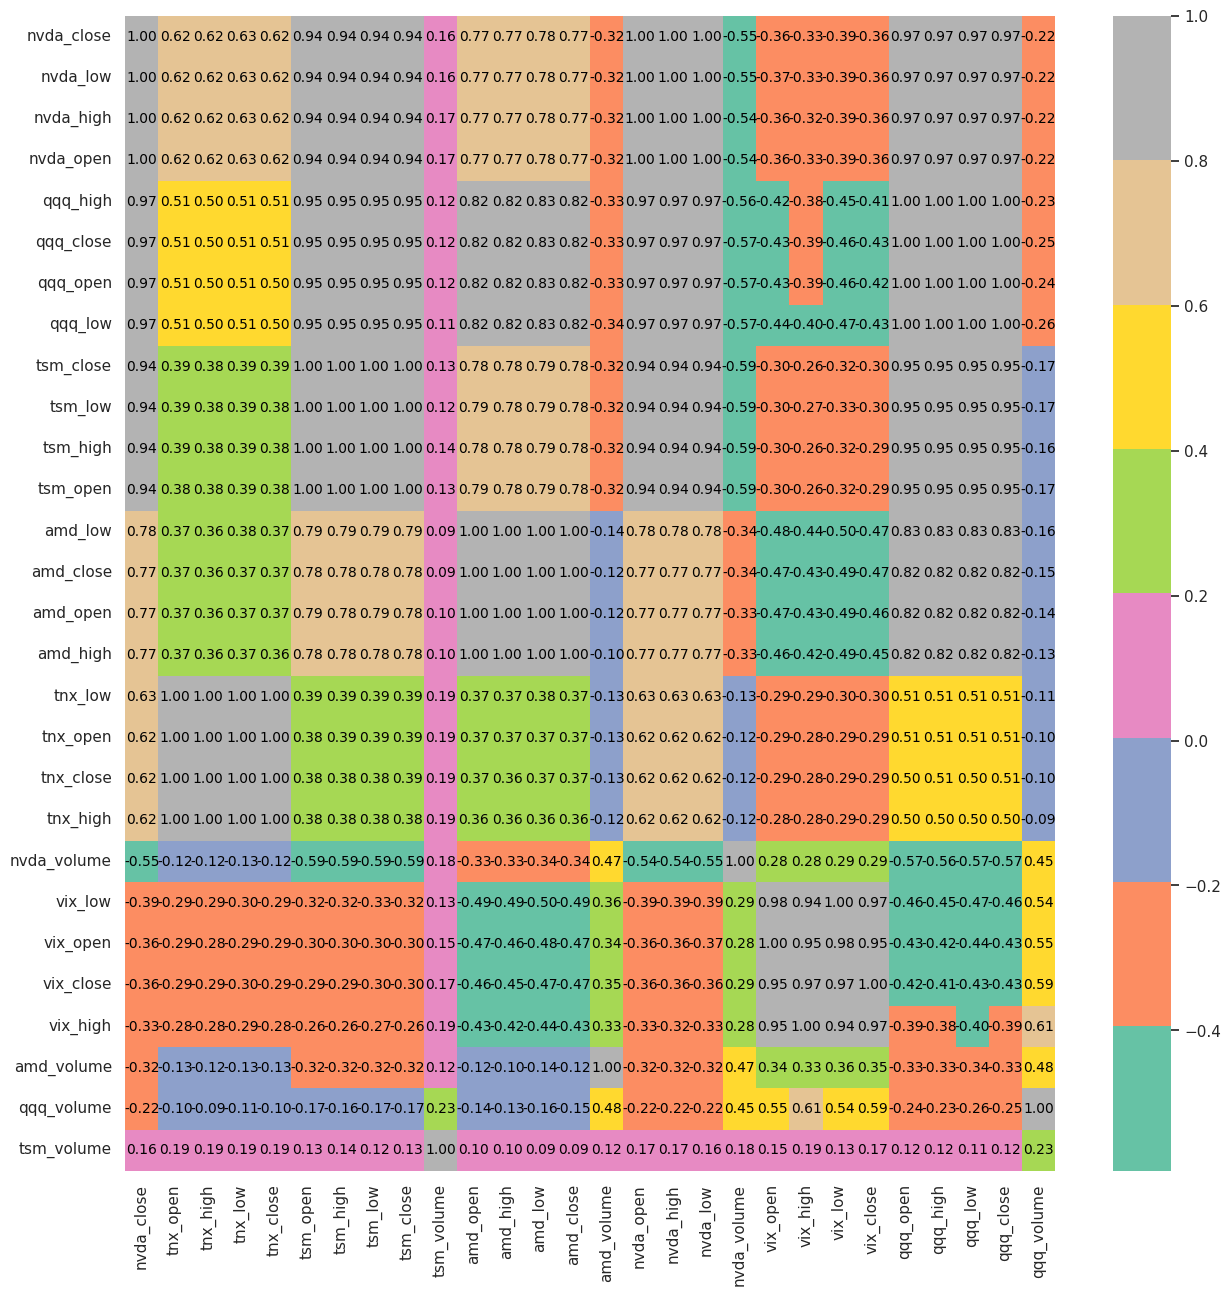

In [14]:
df_corr_raw = df.copy()
corr_matrix_raw = df_corr_raw.corr()
sorted_corr_raw = corr_matrix_raw.loc[
    corr_matrix_raw['nvda_close'].abs().sort_values(ascending=False).index
]
# Define 'cols' specifically for this heatmap, placing 'nvda_close' at the front
# cols_raw = col for col in sorted_corr_raw.columns
cols_raw = ['nvda_close'] + [col for col in sorted_corr_raw.columns if col != 'nvda_close']
df_heatmap_raw = sorted_corr_raw[cols_raw]
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15,15))
sns.heatmap(df_heatmap_raw, annot=True, cmap='Set2', annot_kws={'fontsize': 10, 'color': 'black'}, fmt='.2f')

### Feature Engineering

#### NVDA-Only Features

In [15]:
# Feature Engineer (NVDA-Only)
# ---------- PRICE FEATURES ----------
# Lagged prices (autoregressive features)

df['nvda_lag1_price'] = df['nvda_close'].shift(1)
df['nvda_lag2_price'] = df['nvda_close'].shift(2)
df['nvda_lag3_price'] = df['nvda_close'].shift(3)
df['nvda_lag5_price'] = df['nvda_close'].shift(5)
df['nvda_lag10_price'] = df['nvda_close'].shift(10)
df['nvda_lag20_price'] = df['nvda_close'].shift(20)

df['nvda_lag1_high_price'] = df['nvda_high'].shift(1)
df['nvda_lag2_low_price'] = df['nvda_low'].shift(2)
# Lagged Volumes
df['nvda_lag1_volume'] = df['nvda_volume'].shift(1)
df['nvda_lag2_volume'] = df['nvda_volume'].shift(2)
df['nvda_lag3_volume'] = df['nvda_volume'].shift(3)
df['nvda_lag5_volume'] = df['nvda_volume'].shift(5)
df['nvda_lag10_volume'] = df['nvda_volume'].shift(10)
df['nvda_lag20_volume'] = df['nvda_volume'].shift(20)

# Moving Avg (Different timeframe trends indicators)
df['nvda_roll2_price'] = df['nvda_close'].rolling(2).mean().shift(1)
df['nvda_roll3_price'] = df['nvda_close'].rolling(3).mean().shift(1)
df['nvda_roll5_price'] = df['nvda_close'].rolling(5).mean().shift(1)
df['nvda_roll10_price'] = df['nvda_close'].rolling(10).mean().shift(1)
df['nvda_roll20_price'] = df['nvda_close'].rolling(20).mean().shift(1)

# Distance from a longer moving average
df['nvda_roll2_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll2_price']
df['nvda_roll3_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll3_price']
df['nvda_roll5_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll5_price']
df['nvda_roll10_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll10_price']
df['nvda_roll20_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll20_price']

# How much is price fluctuating?
# Pirce Std - Magnitude Clustering
df['nvda_price_std2'] = df['nvda_close'].rolling(2).std().shift(1)
df['nvda_price_std3'] = df['nvda_close'].rolling(3).std().shift(1)
df['nvda_price_std5'] = df['nvda_close'].rolling(5).std().shift(1)   # Short-term price
df['nvda_price_std10'] = df['nvda_close'].rolling(10).std().shift(1)
df['nvda_price_std20'] = df['nvda_close'].rolling(20).std().shift(1) # Longer-term price

# Return Std - Relative Price Volatility Regime
df['nvda_volatility2'] = df['nvda_close'].pct_change().rolling(2).std().shift(1)
df['nvda_volatility3'] = df['nvda_close'].pct_change().rolling(3).std().shift(1)
df['nvda_volatility5'] = df['nvda_close'].pct_change().rolling(5).std().shift(1)
df['nvda_volatility10'] = df['nvda_close'].pct_change().rolling(10).std().shift(1)
df['nvda_volatility20'] = df['nvda_close'].pct_change().rolling(20).std().shift(1)

# MACD (Moving Average Convergence Divergence)
df['nvda_ema2'] = df['nvda_close'].ewm(span=2, adjust=False).mean().shift(1)
df['nvda_ema3'] = df['nvda_close'].ewm(span=3, adjust=False).mean().shift(1)
df['nvda_ema5'] = df['nvda_close'].ewm(span=5, adjust=False).mean().shift(1)
df['nvda_ema10'] = df['nvda_close'].ewm(span=10, adjust=False).mean().shift(1)
df['nvda_ema20'] = df['nvda_close'].ewm(span=20, adjust=False).mean().shift(1)

# Price Changes
df['nvda_lag1_return'] = df['nvda_close'].pct_change().shift(1)
df['nvda_lag2_return'] = df['nvda_close'].pct_change().shift(2)
df['nvda_lag3_return'] = df['nvda_close'].pct_change().shift(3)
df['nvda_lag5_return'] = df['nvda_close'].pct_change().shift(5)
df['nvda_lag10_return'] = df['nvda_close'].pct_change().shift(10)
df['nvda_lag20_return'] = df['nvda_close'].pct_change().shift(20)

# Trading activity signals
df['nvda_volume_ma2'] = df['nvda_volume'].rolling(2).mean().shift(1)
df['nvda_volume_ma3'] = df['nvda_volume'].rolling(3).mean().shift(1)
df['nvda_volume_ma5'] = df['nvda_volume'].rolling(5).mean().shift(1)
df['nvda_volume_ma20'] = df['nvda_volume'].rolling(20).mean().shift(1)
df['nvda_volume_ma30'] = df['nvda_volume'].rolling(30).mean().shift(1)

df['nvda_price_volume'] = df['nvda_close'].shift(1) * df['nvda_volume'].shift(1)  # Dollar volume
df['nvda_price_volume_ma2'] = df['nvda_price_volume'].rolling(2).mean().shift(1)
df['nvda_price_volume_ma3'] = df['nvda_price_volume'].rolling(3).mean().shift(1)
df['nvda_price_volume_ma5'] = df['nvda_price_volume'].rolling(5).mean().shift(1)
df['nvda_price_volume_ma10'] = df['nvda_price_volume'].rolling(10).mean().shift(1)
df['nvda_price_volume_ma20'] = df['nvda_price_volume'].rolling(20).mean().shift(1)
df['nvda_price_volume_ma30'] = df['nvda_price_volume'].rolling(30).mean().shift(1)

# High-Low range (shifted to avoid data leakage)
df['nvda_high_low_range'] = (df['nvda_high'].shift(1) - df['nvda_low'].shift(1))
df['nvda_high_low_pct'] = ((df['nvda_high'] - df['nvda_low']) / df['nvda_close']).shift(1)

# Indicators
# RSI (Relative Strength Index)
delta = df['nvda_close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['nvda_rsi'] = 100 - (100 / (1 + rs))
df['nvda_rsi'] = df['nvda_rsi'].shift(1)  # Avoid look-ahead bias

# MACD
exp1 = df['nvda_close'].ewm(span=5, adjust=False).mean()
exp2 = df['nvda_close'].ewm(span=10, adjust=False).mean()
df['nvda_macd'] = exp1 - exp2
df['nvda_macd'] = df['nvda_macd'].shift(1)

# Price Momentum
df['nvda_momentum1'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(2)
df['nvda_momentum2'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(3)
df['nvda_momentum3'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(4)
df['nvda_momentum5'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(6)
df['nvda_momentum10'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(11)

df['mom5_x_std2'] = df['nvda_momentum5'] * df['nvda_price_std2']
df['mom5_x_std3'] = df['nvda_momentum5'] * df['nvda_price_std3']
df['mom5_x_std5'] = df['nvda_momentum5'] * df['nvda_price_std5']
df['mom5_x_std10'] = df['nvda_momentum5'] * df['nvda_price_std10']
df['mom5_x_std20'] = df['nvda_momentum5'] * df['nvda_price_std20']

# Calendar Features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['day_of_month'] = df.index.day


# Peer Price
df['amd_lag1_price'] = df['amd_close'].shift(1)
df['tsm_lag1_price'] = df['tsm_close'].shift(1)
df['qqq_lag1_price'] = df['qqq_close'].shift(1)
df['vix_lag1_price'] = df['vix_close'].shift(1)
df['tnx_lag1_price'] = df['tnx_close'].shift(1)

df['tsm_lag2_price'] = df['tsm_close'].shift(2)
df['qqq_lag2_price'] = df['qqq_close'].shift(2)

df['vix_lag5_price'] = df['vix_close'].shift(5)
df['vix_lag10_price'] = df['vix_close'].shift(10)
df['vix_lag15_price'] = df['vix_close'].shift(15)

df['tnx_lag5_price'] = df['tnx_close'].shift(5)
df['tnx_lag10_price'] = df['tnx_close'].shift(10)
df['tnx_lag14_price'] = df['tnx_close'].shift(14)
df['tnx_lag15_price'] = df['tnx_close'].shift(15)

# Peer stock rolling trends
df['qqq_roll3_price'] = df['qqq_close'].rolling(3).mean().shift(1)
df['qqq_roll5_price'] = df['qqq_close'].rolling(5).mean().shift(1)

df['amd_roll3_price'] = df['amd_close'].rolling(3).mean().shift(1)
df['amd_roll5_price'] = df['amd_close'].rolling(5).mean().shift(1)

df['tsm_roll3_price'] = df['tsm_close'].rolling(3).mean().shift(1)
df['tsm_roll5_price'] = df['tsm_close'].rolling(5).mean().shift(1)
df['tsm_roll10_price'] = df['tsm_close'].rolling(10).mean().shift(1)
df['tsm_roll20_price'] = df['tsm_close'].rolling(10).mean().shift(1)

df['amd_ema10'] = df['amd_close'].ewm(span=10, adjust=False).mean().shift(1)
df['tsm_ema20'] = df['tsm_close'].ewm(span=20, adjust=False).mean().shift(1)

# peer risk & rates
df['tsm_price_std2'] = df['tsm_close'].rolling(2).std().shift(1)
df['tsm_price_std3'] = df['tsm_close'].rolling(3).std().shift(1)
df['tsm_price_std5'] = df['tsm_close'].rolling(5).std().shift(1)   # Short-term price
df['tsm_price_std10'] = df['tsm_close'].rolling(10).std().shift(1)
df['tsm_price_std20'] = df['tsm_close'].rolling(20).std().shift(1)

# return qqq Std - Relative Price Volatility Regime
df['qqq_volatility2'] = df['qqq_close'].pct_change().rolling(2).std().shift(1)
df['qqq_volatility3'] = df['qqq_close'].pct_change().rolling(3).std().shift(1)
df['qqq_volatility5'] = df['qqq_close'].pct_change().rolling(5).std().shift(1)
df['qqq_volatility10'] = df['qqq_close'].pct_change().rolling(10).std().shift(1)
df['qqq_volatility20'] = df['qqq_close'].pct_change().rolling(20).std().shift(1)


# return tsm Std - Relative Price Volatility Regime
df['tsm_volatility2'] = df['tsm_close'].pct_change().rolling(2).std().shift(1)
df['tsm_volatility3'] = df['tsm_close'].pct_change().rolling(3).std().shift(1)
df['tsm_volatility5'] = df['tsm_close'].pct_change().rolling(5).std().shift(1)
df['tsm_volatility10'] = df['tsm_close'].pct_change().rolling(10).std().shift(1)
df['tsm_volatility20'] = df['tsm_close'].pct_change().rolling(20).std().shift(1)

df['tnx_lag14_price'] = df['tnx_close'].shift(14)

df = df.copy()
df = df.sort_index()

# time index (t) is added to model long-term price drift
df['t'] = np.arange(len(df));

display(df.head())
print()
display(df.tail())
display(df.shape);

/tmp/ipykernel_4049/613067675.py:152: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tsm_ema20'] = df['tsm_close'].ewm(span=20, adjust=False).mean().shift(1)
/tmp/ipykernel_4049/613067675.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tsm_price_std2'] = df['tsm_close'].rolling(2).std().shift(1)
/tmp/ipykernel_4049/613067675.py:156: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

,tnx_open,tnx_high,tnx_low,tnx_close,tsm_open,tsm_high,tsm_low,tsm_close,tsm_volume,amd_open,...,qqq_volatility3,qqq_volatility5,qqq_volatility10,qqq_volatility20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20,t
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.935,0.953,0.907,0.917,102.502915,104.921345,101.564964,102.714409,11262100,92.110001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2021-01-05,0.937,0.963,0.927,0.955,103.367285,105.702951,102.999461,103.698318,10583600,92.099998,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2021-01-06,1.000,1.054,1.000,1.042,104.691470,107.027143,103.496051,106.309891,10609300,91.620003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2021-01-07,1.056,1.088,1.054,1.071,109.739814,113.050221,108.130591,111.661690,13556100,91.330002,...,NaN,NaN,NaN,NaN,0.011035,NaN,NaN,NaN,NaN,3
2021-01-08,1.088,1.126,1.075,1.105,115.781301,116.130729,107.569665,109.142105,18976800,95.980003,...,0.019105,NaN,NaN,NaN,0.017789,0.020567,NaN,NaN,NaN,4


,tnx_open,tnx_high,tnx_low,tnx_close,tsm_open,tsm_high,tsm_low,tsm_close,tsm_volume,amd_open,...,qqq_volatility3,qqq_volatility5,qqq_volatility10,qqq_volatility20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20,t
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-29,4.247,4.271,4.223,4.227,339.799988,343.739990,328.200012,339.549988,13844800,254.660004,...,0.003057,0.002613,0.010132,0.008175,0.003689,0.012268,0.011466,0.023572,0.021918,1273
2026-01-30,4.247,4.261,4.236,4.241,335.420013,339.899994,329.100006,330.559998,12028100,236.929993,...,0.007594,0.005463,0.009618,0.008294,0.013957,0.013163,0.013962,0.023285,0.022028,1274
2026-02-02,4.236,4.281,4.231,4.275,330.760010,344.200012,329.100006,341.359985,12459100,235.770004,...,0.007719,0.008548,0.010489,0.008548,0.013041,0.019094,0.017321,0.020193,0.023127,1275
2026-02-03,4.290,4.300,4.266,4.274,345.070007,347.049988,330.019989,335.750000,12540000,251.550003,...,0.009642,0.008945,0.010697,0.008635,0.041824,0.030264,0.022983,0.023163,0.021406,1276
2026-02-04,4.268,4.290,4.261,4.275,335.600006,338.799988,319.070007,325.739990,18176000,215.000000,...,0.011985,0.009576,0.009435,0.009214,0.034723,0.031651,0.023619,0.018385,0.021826,1277


(1278, 143)

#### After feature-engineered, the timeframe is now from: 03-30-2021 to 02-04-2026. There are 143 columns and 1278 rows.

## Peason Correlation by NVDA Closing Price

In [16]:
# Feature used for corr() chart purpose
df_corr = df.copy()
df_corr['y_30'] = df_corr['nvda_close'].shift(-30)

# Drop NaNs before correlation
df_corr = df_corr.dropna()

corr_matrix = df_corr.corr()

# Sort by absolute correlation with y_30
sorted_corr = corr_matrix.loc[
    corr_matrix['y_30'].abs().sort_values(ascending=False).index
]

# Move y_30 column to the front
cols = ['y_30'] + [col for col in sorted_corr.columns if col != 'y_30']
df_heatmap = sorted_corr[cols]
df_heatmap.head(60)

,y_30,tnx_open,tnx_high,tnx_low,tnx_close,tsm_open,tsm_high,tsm_low,tsm_close,tsm_volume,...,qqq_volatility3,qqq_volatility5,qqq_volatility10,qqq_volatility20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20,t
y_30,1.000000,0.630207,0.625002,0.634672,0.629035,0.914891,0.915894,0.915882,0.916822,0.176150,...,-0.198950,-0.233464,-0.248960,-0.253853,0.058080,0.063348,0.083709,0.121785,0.148423,0.916814
nvda_close,0.978620,0.613084,0.607616,0.617617,0.611741,0.947816,0.948641,0.948484,0.949124,0.180781,...,-0.195707,-0.234464,-0.258211,-0.272124,0.068981,0.072472,0.087249,0.127676,0.172137,0.907468
nvda_low,0.978309,0.612225,0.606699,0.616783,0.610848,0.948945,0.949452,0.949537,0.949753,0.176392,...,-0.199699,-0.238830,-0.261916,-0.275303,0.065956,0.068438,0.082723,0.123142,0.168180,0.906682
nvda_high,0.977973,0.613468,0.608023,0.617978,0.612128,0.947771,0.948497,0.947959,0.948428,0.187994,...,-0.193271,-0.232026,-0.256508,-0.270765,0.070635,0.074947,0.090009,0.129092,0.174474,0.907687
nvda_lag1_price,0.977636,0.612397,0.606912,0.616943,0.611023,0.948279,0.948725,0.948312,0.948525,0.184183,...,-0.195041,-0.233649,-0.257666,-0.271727,0.069655,0.074383,0.089178,0.126392,0.171356,0.907113
nvda_open,0.977594,0.612534,0.606995,0.617059,0.611124,0.948712,0.949046,0.948723,0.948864,0.183762,...,-0.195814,-0.235039,-0.259032,-0.273261,0.069524,0.072931,0.087072,0.126074,0.171080,0.906777
nvda_ema2,0.977518,0.612255,0.606780,0.616798,0.610902,0.948359,0.948891,0.948399,0.948689,0.185793,...,-0.194638,-0.233590,-0.257196,-0.271585,0.069921,0.074862,0.090042,0.126589,0.171119,0.907262
nvda_roll2_price,0.977407,0.612179,0.606714,0.616729,0.610839,0.948213,0.948769,0.948278,0.948590,0.186145,...,-0.194938,-0.233891,-0.257303,-0.271618,0.069346,0.074466,0.089792,0.126317,0.171066,0.907164
nvda_ema3,0.977333,0.612064,0.606593,0.616598,0.610721,0.948402,0.948995,0.948433,0.948778,0.186936,...,-0.193745,-0.232994,-0.256492,-0.271297,0.070754,0.075808,0.091194,0.127163,0.170916,0.907323
nvda_roll3_price,0.977088,0.611929,0.606459,0.616465,0.610594,0.948158,0.948774,0.948191,0.948555,0.187457,...,-0.194261,-0.233568,-0.256678,-0.271375,0.070138,0.075215,0.090870,0.126668,0.170842,0.907144


#### The 30-day target is most strongly correlated with NVDA’s own lagged and rolling price features, confirming the dominance of autoregressive structure in price forecasting. Cross-asset features (QQQ, TSM, AMD) and volatility measures exhibit weaker but still meaningful correlations, indicating potential secondary predictive influence.

### Time-Based Train-Test-Split
#### The dataset was split chronologically, using Feb 3, 2025 as the cutoff point, to create a sufficiently long training window while preserving a meaningful out-of-sample period for testing. This preserves data integrity and prevents look-ahead bias in the time-series evaluation.

In [17]:
split_date = pd.to_datetime('2025-02-03') # first business date in Feb, 2025

MAE, RSME, MAPE Metric Function

In [18]:
def evaluate_direct_price_model(
    df,
    feature_cols,
    horizon,
    split_date,
    model,
    scale=False
):

    df_model = df.copy()

    # Create dynamic target
    df_model['y'] = df_model['nvda_close'].shift(-horizon)

    # Keep only needed columns
    df_model = df_model[feature_cols + ['y']]

    # Drop NaNs safely
    df_model = df_model.dropna()

    # Split
    train = df_model[df_model.index < split_date]
    test  = df_model[df_model.index >= split_date]

    X_train = train[feature_cols]
    y_train = train['y']

    X_test  = test[feature_cols]
    y_test  = test['y']

    # Optional scaling (for Lasso / Ridge)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    # Fit model
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    results = {
        "Horizon": horizon,
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE":  mean_absolute_error(y_test, y_pred_test),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Train_MAPE": mean_absolute_percentage_error(y_train, y_pred_train),
        "Test_MAPE":  mean_absolute_percentage_error(y_test, y_pred_test)
    }

    return results, model, test.index, y_test, y_pred_test

## Linear Regression Price-Based Models

### 1. Baseline: NVDA-Only Features Model  
#### Uses only NVDA’s historical price and technical features.

In [19]:
X_cols_uni = [
'nvda_lag1_price',

# Lagged Volumes
'nvda_lag2_volume',

# Moving Avg (Different timeframe trends indicators)
'nvda_roll3_dist_price',

# How much is price fluctuating?
'nvda_price_std2',

# Price Regime Volatility
'nvda_volatility2',
'nvda_volatility3',
'nvda_volatility5',
'nvda_volatility10',
'nvda_volatility20',

# MACD (Moving Average Convergence Divergence)
'nvda_ema2', #deleted

# Trading activity signals
'nvda_volume_ma20',

# Indicators
## RSI (Relative Strength Index)
'nvda_rsi' ,  # Avoid look-ahead bias  # deleted

# Price Momentum

'nvda_momentum5',
# 'nvda_momentum10',

'mom5_x_std10',
't',

'nvda_ema5',

]

### 2. Extended: NVDA + Cross-Asset Features Model  
#### Incorporates selected NVDA, peer, and market signals.

In [20]:
X_cols_mul = [
'nvda_lag1_price',
'nvda_lag2_price',

# Moving Avg (Different timeframe trends indicators)
'nvda_roll3_price',

# How much is price fluctuating?
'nvda_price_std2',

# Price Regime Volatility
'nvda_volatility3',

# MACD (Moving Average Convergence Divergence)
'nvda_ema20',

# Price Changes
'nvda_lag5_return',

# Trading activity signals
'nvda_volume_ma30',

# High-Low range (shifted to avoid data leakage)
'nvda_high_low_range',

# MACD
'nvda_macd',

# Price Momentum
'nvda_momentum10',
'mom5_x_std20',

# Peer Price
'tsm_close',
'tnx_lag15_price',
'qqq_close',

# Price Regime
'qqq_roll5_price',
'tsm_roll10_price',
'tsm_ema20' ,
'tsm_price_std20',
'tsm_volatility2',
'tsm_volatility3',
'tsm_volatility5',
'tsm_volatility10',
'tsm_volatility20',

't',

'tnx_lag15_price',
]

#### Compare Both NVDA-Only and NVDA + Cross Asset Models

In [21]:
# Horizons (Various timeframes)
horizons = [1, 5, 10, 20, 30]

# NVDA Only Model
results_lr_uni = []

for h in horizons:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        model=LinearRegression(),
        feature_cols=X_cols_uni,
        horizon=h,
        split_date=split_date,
        scale=False
    )
    results_lr_uni.append(metrics)

price_lr_uni_df = pd.DataFrame(results_lr_uni)
print('========================= NVDA Features LR Model ========================')
display(price_lr_uni_df)
print()

# NVDA + Cross Asset Model
results_lr_mul = []

for h in horizons:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        model = LinearRegression(),
        feature_cols=X_cols_mul,
        horizon=h,
        split_date=split_date,
        scale=False
    )
    results_lr_mul.append(metrics)

price_lr_mul_df = pd.DataFrame(results_lr_mul)
print('================== NVDA + Cross Asset Features LR Model ================')
display(price_lr_mul_df)

========================= NVDA Features LR Model ========================


,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.727115,4.013615,2.830723,5.179395,0.039445,0.027110
1,5,2.942056,6.581162,4.632206,8.366870,0.067881,0.044756
2,10,3.856185,8.473308,5.931200,10.603721,0.091402,0.057579
3,20,5.201606,11.609038,7.794316,13.714031,0.125035,0.080361
4,30,6.320913,14.021862,9.517918,16.984616,0.149767,0.096125



================== NVDA + Cross Asset Features LR Model ================


,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.665695,3.729035,2.690231,4.873886,0.040032,0.024870
1,5,2.942374,6.605796,4.572735,8.312099,0.067560,0.044740
2,10,3.836428,9.606711,5.635885,11.842151,0.097534,0.065892
3,20,5.262251,13.157644,7.464378,15.923014,0.133620,0.092050
4,30,6.434173,14.284385,9.211387,17.570853,0.172939,0.100168


#### Interpretation:

- Cross-asset features provide meaningful gains at shorter horizons (1-5 days), indicating that market and peer signals enhance near-term predictive accuracy.
- At longer horizons (20-30 days), the advantage diminishes, implying that longer-term price movement is driven more by NVDA’s own trend structure than external signals..


### 3. Regularized: Lasso Regression  
#### Performs automatic feature selection and controls overfitting.


In [22]:
X_cols_lasso = [
'nvda_lag1_price',
'nvda_lag2_price',
'nvda_lag3_price',
'nvda_lag5_price',
'nvda_lag1_volume',
'nvda_lag2_volume',
'nvda_roll3_price',
'nvda_price_std2',
'nvda_volatility3',
'nvda_volatility10',
'nvda_volatility20',
'nvda_ema20',
'nvda_lag5_return',
'nvda_volume_ma2',
'nvda_volume_ma30',
'nvda_high_low_range',
'nvda_macd',
'nvda_momentum10',
'mom5_x_std20',
'tsm_close',
'qqq_close',
'qqq_roll5_price',
'tsm_roll10_price',
'tsm_ema20' ,
'qqq_lag1_price',
'tsm_lag2_price',
'tnx_lag1_price',
'tnx_lag5_price',
'tnx_lag14_price',
'tsm_price_std20',
'tsm_volatility2',
'tsm_volatility3',
'tsm_volatility5',
'tsm_volatility10',
'tsm_volatility20',
't',

]

In [23]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
results_lasso = []

for h in [1, 5, 10, 20, 30]:  # multiple horizons

    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        feature_cols=X_cols_lasso,
        horizon=h,
        split_date=split_date,
        model=Lasso(alpha=0.05, max_iter=10000, random_state=42),
        scale=True
    )
    results_lasso.append(metrics)

price_lasso_df = pd.DataFrame(results_lasso)
display(price_lasso_df)

,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.691251,4.346489,2.806247,5.611398,0.037910,0.028725
1,5,2.906611,6.626559,4.581431,8.372528,0.066537,0.044821
2,10,3.813298,8.693732,5.686366,10.768853,0.095262,0.059777
3,20,5.260056,12.014341,7.520352,14.480079,0.133230,0.084489
4,30,6.308938,13.257073,9.273386,16.046751,0.165902,0.092474


#### Interpretation:

##### Lasso underperforms the cross-asset model at short horizons but becomes more competitive at longer horizons. The regularization effect improves generalization by limiting redundant predictors, resulting in more stable long-horizon forecasts.

In [24]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5]

for a in alphas:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        feature_cols=X_cols_mul,
        horizon=30,
        split_date=split_date,
        model=Lasso(alpha=a, max_iter=10000, random_state=42),
        scale=True
    )
    n_zero = np.sum(model.coef_ == 0)

    print(f"Alpha: {a:>4} | RMSE: {metrics['Test_RMSE']:.4f} | Zero Coefs: {n_zero}")

Alpha: 0.01 | RMSE: 17.1053 | Zero Coefs: 5
Alpha: 0.05 | RMSE: 16.2105 | Zero Coefs: 10
Alpha:  0.1 | RMSE: 16.4630 | Zero Coefs: 12
Alpha:  0.5 | RMSE: 17.1191 | Zero Coefs: 22
Alpha:    1 | RMSE: 17.8298 | Zero Coefs: 22
Alpha:    5 | RMSE: 24.1486 | Zero Coefs: 24


Moderate regularization (α ≈ 0.05–0.1) achieves the best tradeoff between bias and variance, whereas higher penalties lead to underfitting. Although regularization does not dramatically reduce forecast error, it simplifies and optimize the model.

### Find Coefficients in Lasso Regression

In [25]:
coef = model.coef_
sum(coef == 0)

np.int64(24)

In [27]:
coef_df = pd.DataFrame({
    'Feature': X_cols_mul,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df = coef_df.sort_values(by='Abs_Coefficient', key= abs, ascending=False)
display(coef_df.head(60))

ValueError: All arrays must be of the same length

Although many candidate features were included, Lasso retained only a few key predictors—primarily NVDA’s lagged price, trend, and a limited set of market signals. The large number of zeroed coefficients suggests that many engineered features capture overlapping information, and removing them helped stabilize out-of-sample performance.

### Linear Regression Lasso Direct 30 Day Chart

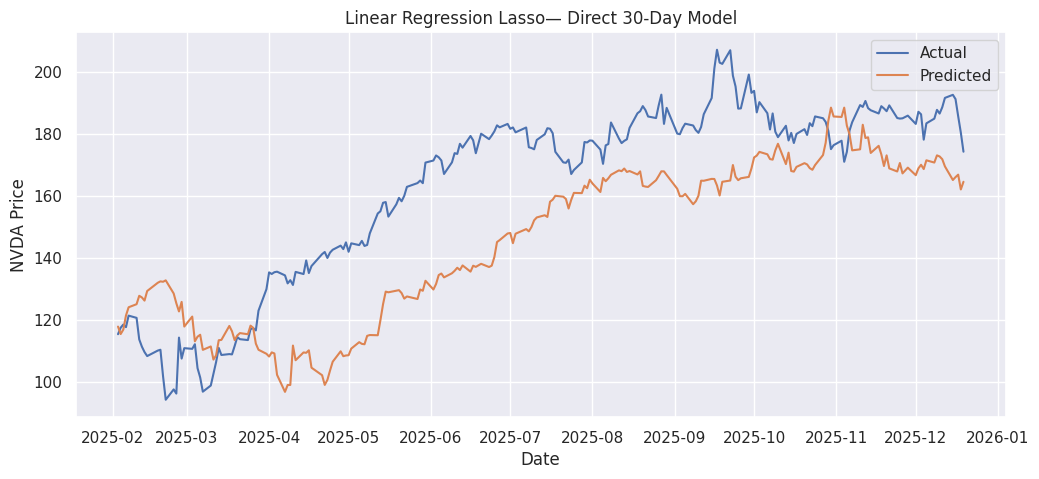

In [28]:
results_lasso
plt.figure(figsize=(12,5))
plt.plot(test_idx, y_test, label='Actual')
plt.plot(test_idx, y_pred, label='Predicted')
plt.title('Linear Regression Lasso— Direct 30-Day Model')
plt.xlabel('Date')
plt.ylabel('NVDA Price')
plt.legend()
plt.show()

The 30-day Lasso forecast captures the overall upward trend in NVDA’s price but smooths short-term fluctuations, reflecting the model’s reliance on dominant autoregressive structure and drift. While the model tracks direction reasonably well, the lag in peak and pullback periods is consistent with the observed 30-day test RMSE (~16.05), indicating moderate long-horizon forecasting uncertainty.

### 4. Return-Based Models
#### Evaluates predictive performance using return targets.

##### Instead of predicting future price levels, this model predicts future returns and converts them back to price for comparison using:
future_price = last_price × (1 + predicted_return).

##### Price levels exhibit strong persistence (e.g., corr(y_30, nvda_price_lag1) ≈ 0.98), meaning a price-based model may rely heavily on autoregressive structure. Modeling returns reduces this persistence and forces the model to learn underlying relationships rather than simply extending recent price levels.

##### Return modeling does not necessarily produce dramatically lower MAE, but it improves:

- Statistical correctness

- Stability across regimes

- Compatibility with nonlinear models

#### Train, Test, Split and Model Function

In [29]:
# import numpy as np
# import pandas as pd

# from sklearn.metrics import mean_squared_error
from sklearn.base import clone

def eval_return_model_to_price_rmse(
    df: pd.DataFrame,
    feature_cols: list[str],
    horizon: int,
    split_date: pd.Timestamp,
    model,
    model_name: str,
    price_col: str = "nvda_close",
    compute_return_rmse: bool = False,  # optional diagnostic
):
    """
    Trains a return-based model for a given horizon and evaluates in PRICE space (RMSE).
    Optionally also returns return-space RMSE as a diagnostic.

    Assumes df has:
      - price_col (e.g. nvda_close)
      - feature columns already engineered (return-based features live in df)
      - DateTimeIndex
    """

    df_loop = df.copy()

    # Target: H-step return
    y_col = f"y_ret_{horizon}"
    df_loop[y_col] = df_loop[price_col].pct_change(horizon).shift(-horizon)

    # Keep needed columns, drop NaNs
    needed = feature_cols + [price_col, y_col]
    df_loop = df_loop.dropna(subset=needed)

    # Split
    train = df_loop[df_loop.index < split_date]
    test  = df_loop[df_loop.index >= split_date]

    X_train = train[feature_cols]
    y_train = train[y_col]

    X_test  = test[feature_cols]
    y_test  = test[y_col]

    # Current price at t (for converting predicted return to predicted price at t+H)
    current_price = test[price_col]
    actual_future_price = test[price_col].shift(-horizon)

    # Fit / predict
    m = clone(model)
    m.fit(X_train, y_train)
    pred_ret = m.predict(X_test)

    # Optional diagnostic in return-space
    ret_rmse = None
    if compute_return_rmse:
        ret_rmse = float(np.sqrt(mean_squared_error(y_test, pred_ret)))

    # Convert to price
    pred_price = current_price * (1 + pred_ret)

    # Align safely (drop last H rows where future price is NaN)
    valid = actual_future_price.notna()
    actual = actual_future_price[valid]
    pred   = pred_price[valid]

    price_rmse = float(np.sqrt(mean_squared_error(actual, pred)))

    row = {
        "Model": model_name,
        "Horizon": horizon,
        "RMSE": price_rmse
    }
    if compute_return_rmse:
        row["Return_RMSE_Diag"] = ret_rmse

    return row, m

### Return-Based Feature Engineer

In [30]:
# Add Momentum
df_ret_model= df.copy()

df_ret_model['nvda_ret1'] = df_ret_model['nvda_close'].pct_change(1).shift(1)
df_ret_model['nvda_ret5'] = df_ret_model['nvda_close'].pct_change(5).shift(1)

df_ret_model['nvda_ret_roll5']  = df_ret_model['nvda_ret1'].rolling(5).mean()
df_ret_model['nvda_ret_roll10'] = df_ret_model['nvda_ret1'].rolling(10).mean()

df_ret_model['nvda_ret_vol5'] = (
    df_ret_model['nvda_close'].pct_change()
    .rolling(5)
    .std()
    .shift(1)
)

# Add Volatility
df_ret_model['nvda_ret_vol5']  = df_ret_model['nvda_ret1'].rolling(5).std()
df_ret_model['nvda_ret_vol10'] = df_ret_model['nvda_ret1'].rolling(10).std()

df_ret_model['tsm_ret1'] = df_ret_model['tsm_close'].pct_change().shift(1)
df_ret_model['tsm_ret3']  = df_ret_model['tsm_close'].pct_change(3).shift(1)
df_ret_model['tsm_ret3']  = df_ret_model['tsm_close'].pct_change(3).shift(1)
df_ret_model['tsm_ret10'] = df_ret_model['tsm_close'].pct_change(10).shift(1)
df_ret_model['tsm_ret20'] = df_ret_model['tsm_close'].pct_change(20).shift(1)

df_ret_model['qqq_ret1'] = df_ret_model['qqq_close'].pct_change().shift(1)
df_ret_model['qqq_ret3'] = df_ret_model['qqq_close'].pct_change().shift(3)
df_ret_model['qqq_ret5'] = df_ret_model['qqq_close'].pct_change().shift(5)
df_ret_model['qqq_ret15'] = df_ret_model['qqq_close'].pct_change().shift(15)
df_ret_model['vix_ret1'] = df_ret_model['vix_close'].pct_change().shift(1)
df_ret_model['vix_ret3'] = df_ret_model['vix_close'].pct_change().shift(3)

df_ret_model['amd_ret1'] = df_ret_model['amd_close'].pct_change().shift(1)
df_ret_model['amd_ret3']  = df_ret_model['amd_close'].pct_change(3).shift(1)
df_ret_model['amd_ret5']  = df_ret_model['amd_close'].pct_change(5).shift(1)
df_ret_model['amd_ret10'] = df_ret_model['amd_close'].pct_change(10).shift(1)
df_ret_model['amd_ret20'] = df_ret_model['amd_close'].pct_change(20).shift(1)

df_ret_model['tnx_ret1'] = df_ret_model['tnx_close'].pct_change().shift(1)
df_ret_model['tnx_ret3'] = df_ret_model['tnx_close'].pct_change().shift(3)
# Add Peer Momentum
df_ret_model['tsm_ret_roll5'] = df_ret_model['tsm_ret1'].rolling(5).mean()
df_ret_model['amd_ret_roll5'] = df_ret_model['amd_ret1'].rolling(5).mean()
df_ret_model['qqq_ret_roll5'] = df_ret_model['qqq_ret1'].rolling(5).mean()

df_ret_model['tsm_vol10'] = (
    df_ret_model['tsm_close']
    .pct_change()
    .rolling(10)
    .std()
    .shift(1)
)

df_ret_model['nvda_mom5'] = (
    df_ret_model['nvda_close'].shift(1)
    - df_ret_model['nvda_close'].shift(6)
)

df_ret_model['tsm_mom10'] = (
    df_ret_model['tsm_close'].shift(1)
    - df_ret_model['tsm_close'].shift(11)
)

df_ret_model['t'] = np.arange(len(df_ret_model))

display(df_ret_model.columns)


Index(['tnx_open', 'tnx_high', 'tnx_low', 'tnx_close', 'tsm_open', 'tsm_high',
       'tsm_low', 'tsm_close', 'tsm_volume', 'amd_open',
       ...
       'amd_ret10', 'amd_ret20', 'tnx_ret1', 'tnx_ret3', 'tsm_ret_roll5',
       'amd_ret_roll5', 'qqq_ret_roll5', 'tsm_vol10', 'nvda_mom5',
       'tsm_mom10'],
      dtype='object', length=172)

In [31]:
# Define Feature Selection

# Simple model
X_simple_cols = [
    'nvda_ret1',
]

# Expanded model
# RETURNED BASED WITH ADDED ROLLING Momentum & Volatility
X_exp_cols = [
    'nvda_ret1',
    'nvda_ret_roll5',
    'nvda_ret_vol5',
    'amd_ret3',

    'qqq_ret1',
    'tsm_ret1',

    'amd_ret_roll5',
    'qqq_ret15',
    'vix_ret3',
    'tnx_ret3',
    'tsm_vol10',

]

In [32]:
def run_return_model_across_horizons(
    df,
    feature_cols,
    horizons,
    split_date,
    model,
    model_name,
    compute_return_rmse=False
):
    rows = []
    fitted_models = {}

    for h in horizons:
        row, fitted = eval_return_model_to_price_rmse(
            df=df,
            feature_cols=feature_cols,
            horizon=h,
            split_date=split_date,
            model=model,
            model_name=model_name,
            compute_return_rmse=compute_return_rmse
        )
        rows.append(row)
        fitted_models[h] = fitted

    return pd.DataFrame(rows), fitted_models

### Return-Based Simple Linear Regression and Return-Based Random Forest

When restricted to a pure autoregressive specification, the return-based simple feature model performs as well as or better than the expanded feature model across horizons. The additional volatility and cross-asset return features do not yield meaningful improvement in predictive performance. Consequently, the return-based simple model is retained for comparison with other forecasting approaches.

#### RandomForest GridSearchCV

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 0.8]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, y_train)
rf_grid.best_estimator_

RandomForestRegressor(max_depth=8, max_features=0.8, min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

#### Hyperparameter from a RandomForest GridSearchCV produces a weaker performance. Therefore, a set of conservative parameters are applied.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

horizons = [1, 5, 10, 20, 30]
split_date = pd.to_datetime("2025-02-03")

# Return Simple LR
ret_lr_price_df, ret_lr_models = run_return_model_across_horizons(
    df=df_ret_model,
    feature_cols=X_simple_cols, # Retained for better performance
    horizons=horizons,
    split_date=split_date,
    model=LinearRegression(),
    model_name="Return_Simple_LR",
    compute_return_rmse=False
)

# Return RF
ret_rf_price_df, ret_rf_models = run_return_model_across_horizons(
    df=df_ret_model,
    feature_cols=X_exp_cols,
    horizons=horizons,
    split_date=split_date,
    model=RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ),
    model_name="Return_RF",
    compute_return_rmse=False
)

display(ret_lr_price_df)
display(ret_rf_price_df)

,Model,Horizon,RMSE
0,Return_Simple_LR,1,3.875211
1,Return_Simple_LR,5,8.194673
2,Return_Simple_LR,10,11.211631
3,Return_Simple_LR,20,15.755067
4,Return_Simple_LR,30,20.455146


,Model,Horizon,RMSE
0,Return_RF,1,3.929155
1,Return_RF,5,8.451344
2,Return_RF,10,11.243315
3,Return_RF,20,17.422150
4,Return_RF,30,23.073211


### Price Compare Between Returned-Based and Price-Based Models
MAPE metrics is fine for price models, but it explodes when returns are near 0. MSE is squared dollars, the scale becomes uninintuitive. RMSE penalizes large forecast errors and is in the same unit as the price model so it is directly interpretable.  Model comparisons will be based primarily on out-of-sample RMSE.

### Use Random Forest to find feature importance

In [34]:
h_pick = 30
rf_m = ret_rf_models[h_pick]

feat_imp = (
    pd.DataFrame({"Feature": X_exp_cols, "Importance": rf_m.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feat_imp.head(20))

,Feature,Importance
0,tsm_vol10,0.204186
1,nvda_ret_vol5,0.150616
2,amd_ret_roll5,0.098492
3,nvda_ret_roll5,0.084497
4,tnx_ret3,0.074139
5,qqq_ret15,0.074107
6,amd_ret3,0.070835
7,vix_ret3,0.065811
8,qqq_ret1,0.059651
9,tsm_ret1,0.059253


This return-based random forest model places greater weight on short-term volatility and sector-level signals rather than NVDA’s own recent returns. Semiconductor peers (TSM, AMD), market volatility (VIX), and interest rate movements (TNX) all contribute meaningful importance to predictive performance. This indicates that NVDA’s short-term price movements are sensitive to broader sector and macro conditions rather than purely autoregressive momentum.

In [35]:
price_lasso_final = price_lasso_df[[
    "Horizon",
    "Test_MAE",
    "Test_RMSE",
    "Test_MAPE"
]].copy()

price_lasso_final["Model"] = "Price_Lasso"

price_lasso_final = price_lasso_final.rename(columns={
    "Test_MAE": "MAE",
    "Test_RMSE": "RMSE",
    "Test_MAPE": "MAPE"
})

price_lasso_final = price_lasso_final[[
    "Model", "Horizon", "MAE", "RMSE", "MAPE"
]]

display(price_lasso_final)

,Model,Horizon,MAE,RMSE,MAPE
0,Price_Lasso,1,4.346489,5.611398,0.028725
1,Price_Lasso,5,6.626559,8.372528,0.044821
2,Price_Lasso,10,8.693732,10.768853,0.059777
3,Price_Lasso,20,12.014341,14.480079,0.084489
4,Price_Lasso,30,13.257073,16.046751,0.092474
